In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
import insitupy
from insitupy._core.data import InSituData,ImageData, CACHE
from insitupy import InSituExperiment
from insitupy.io import read_xenium
import scanpy as sc

### Loading InSitu-Experiment

In [3]:
exp = InSituExperiment.from_config(config_path="/Volumes/KINGSTON/Xenium/insitupy_exp.csv")

100%|██████████| 10/10 [00:00<00:00, 370.08it/s]


In [4]:
exp.load_all()

  0%|          | 0/10 [00:00<?, ?it/s]/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
 10%|█         | 1/10 [00:01<00:09,  1.06s/it]/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
 20%|██        | 2/10 [00:01<00:05,  1.45it/s]/opt/anaconda3/envs/insitupy/lib/python3.10/site-p

In [5]:
exp

InSituExperiment with 10 samples:
           uid  CITAR slide_id    sample_id       sample patient     sample_type
0     6a5e4f99  +++--  0017313    N-42-20-T    N-42-20-T       1  initial dia...
1     7459e1a0  +++--  0017313  N-1055-20-T  N-1055-20-T       1       relapse 1
2     3fbe0a25  +++--  0017313   N-480-21-T   N-480-21-T       1       relapse 2
3     527240b8  +++--  0017313   N-486-22-T   N-486-22-T       2  initial dia...
4     8e2c16a3  +++--  0017313   N-245-23-T   N-245-23-T       2       relapse 1
5     5ddcbd95  +++--  0017321  N-1993-15-T  N-1993-15-T       3  initial dia...
6     8745b0ad  +++--  0017321  N-1445-19-T  N-1445-19-T       3       relapse 1
7     0df035f5  +++--  0017321  N-2070-20-T  N-2070-20-T       3       relapse 2
8     505b76cf  +++--  0017321   N-436-21-T   N-436-21-T       4  initial dia...
9     083b6fcb  +++--  0017321   N-851-22-T   N-851-22-T       4       relapse 1

### Generating pseudobulk without consideration of neighborhood

In [6]:
import decoupler as dc
from insitupy.tools import extract_adata_from_InSituExperiment,concatenate_adatas_for_pseudobulk

/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
adatas=extract_adata_from_InSituExperiment(exp=exp, cell_layer='proseg')
    
pseudobulks={}
    
for id, adata in adatas.items():
        adata.X=adata.layers['round_raw_counts'].copy()
        pdata = dc.pp.pseudobulk(adata=adata,sample_col='batch',groups_col='celltype', mode="sum") 
        pseudobulks[id]=pdata
        
pdata_without_neighborhood=concatenate_adatas_for_pseudobulk(pseudobulks,label='batch')

In [8]:
pdata_without_neighborhood

AnnData object with n_obs × n_vars = 129 × 314
    obs: 'batch', 'celltype', 'scale', 'patient_id', 'sample_type', 'tumor_area', '_scvi_batch', '_scvi_labels', '_scvi_sample', 'psbulk_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [9]:
pdata_without_neighborhood.obs

,batch,celltype,scale,patient_id,sample_type,tumor_area,_scvi_batch,_scvi_labels,_scvi_sample,psbulk_cells,psbulk_counts
N-42-20-T_CAFs,N-42-20-T,CAFs,1.0,1,initial diagnosis,tumor center,0,0,0,313.0,90636.0
N-42-20-T_SMC,N-42-20-T,SMC,1.0,1,initial diagnosis,tumor center,0,1,0,391.0,74549.0
N-42-20-T_endothelial cells,N-42-20-T,endothelial cells,1.0,1,initial diagnosis,tumor center,0,2,0,3400.0,527758.0
N-42-20-T_fibroblast,N-42-20-T,fibroblast,1.0,1,initial diagnosis,tumor center,0,3,0,2218.0,441622.0
N-42-20-T_macrophages/microglia,N-42-20-T,macrophages/microglia,1.0,1,initial diagnosis,tumor center,0,4,0,6989.0,1105512.0
...,...,...,...,...,...,...,...,...,...,...,...
N-851-22-T_t-cells,N-851-22-T,t-cells,1.0,4,relapse 1,tumor center,5,8,5,1067.0,101432.0
N-851-22-T_tumor cells (MES-like),N-851-22-T,tumor cells (MES-like),1.0,4,relapse 1,tumor center,5,9,5,8228.0,1890584.0
N-851-22-T_tumor cells (glia-cells),N-851-22-T,tumor cells (glia-cells),1.0,4,relapse 1,tumor center,5,10,5,270.0,35586.0
N-851-22-T_tumor cells (immune escaping (CD47),N-851-22-T,tumor cells (immune escaping (CD47),1.0,4,relapse 1,tumor center,5,11,5,33411.0,3365696.0


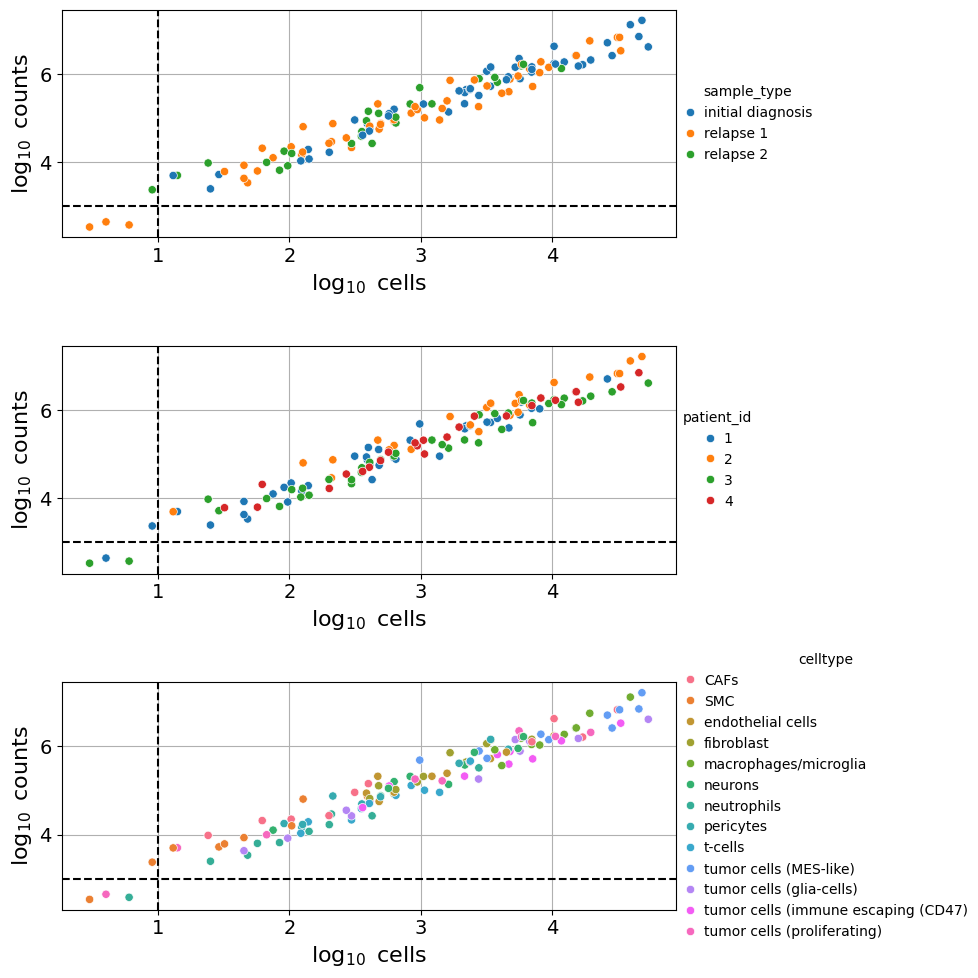

In [10]:
dc.pl.filter_samples(
    adata=pdata_without_neighborhood,
    groupby=["sample_type", "patient_id", "celltype"],
    min_cells=10,
    min_counts=1000,
    figsize=(10, 10),
)

In [11]:
dc.pp.filter_samples(pdata_without_neighborhood, min_cells=10, min_counts=1000)

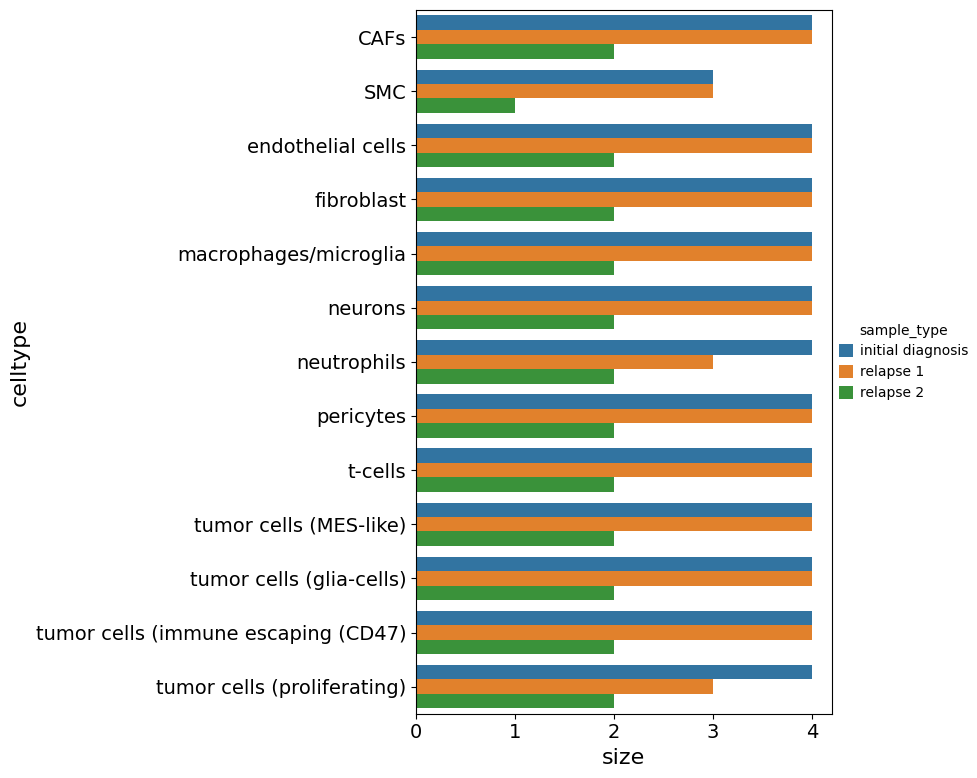

In [12]:
dc.pl.obsbar(adata=pdata_without_neighborhood, y="celltype", hue="sample_type", figsize=(10, 8))

In [13]:
# Store raw counts in layers
pdata_without_neighborhood.layers["counts"] = pdata_without_neighborhood.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata_without_neighborhood, target_sum=1e4)
sc.pp.log1p(pdata_without_neighborhood)
sc.pp.scale(pdata_without_neighborhood, max_value=10)
sc.tl.pca(pdata_without_neighborhood)

# Return raw counts to X
dc.pp.swap_layer(adata=pdata_without_neighborhood, key="counts", inplace=True)

In [14]:
pdata_without_neighborhood

AnnData object with n_obs × n_vars = 125 × 314
    obs: 'batch', 'celltype', 'scale', 'patient_id', 'sample_type', 'tumor_area', '_scvi_batch', '_scvi_labels', '_scvi_sample', 'psbulk_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts', 'X'

In [15]:
pdata_without_neighborhood.obs.keys()


Index(['batch', 'celltype', 'scale', 'patient_id', 'sample_type', 'tumor_area',
       '_scvi_batch', '_scvi_labels', '_scvi_sample', 'psbulk_cells',
       'psbulk_counts'],
      dtype='object')

#### all columns in obs must have at least 2 different features

In [16]:
del pdata_without_neighborhood.obs['tumor_area']

In [17]:
del pdata_without_neighborhood.obs['_scvi_batch']

In [18]:
del pdata_without_neighborhood.obs['_scvi_labels']

In [19]:
del pdata_without_neighborhood.obs['_scvi_sample']

In [20]:
del pdata_without_neighborhood.obs['scale']

In [21]:
dc.tl.rankby_obsm(pdata_without_neighborhood, key="X_pca")

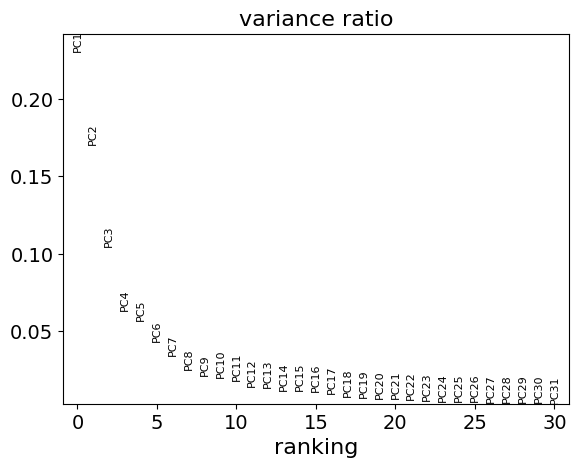

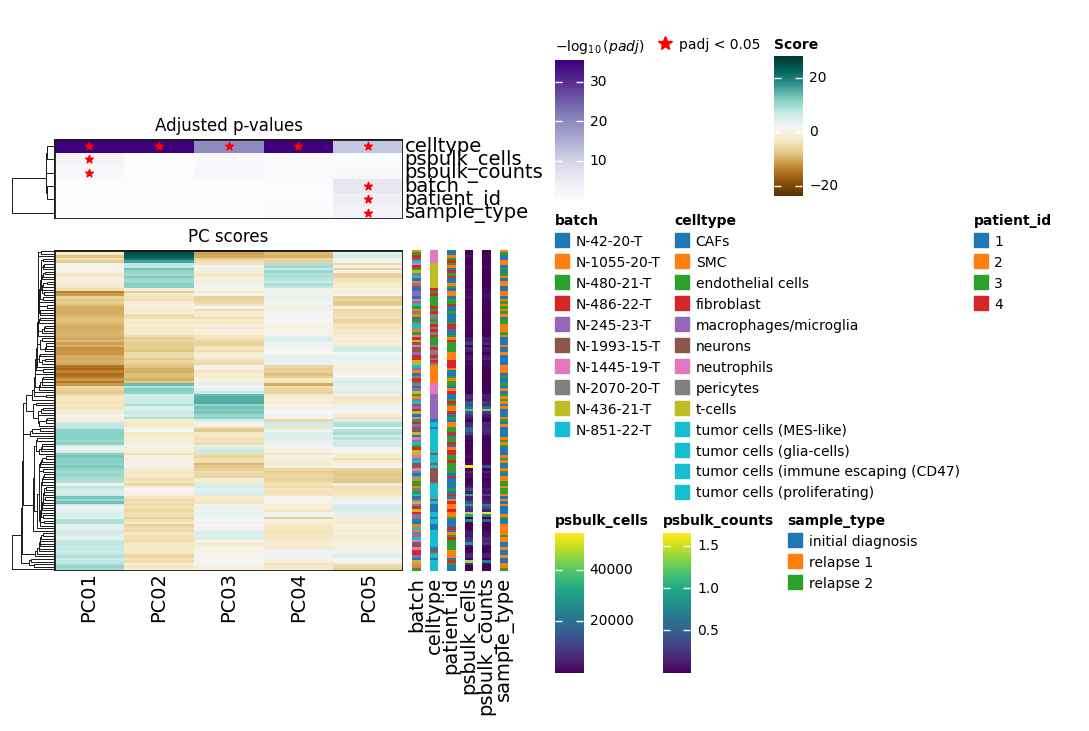

In [22]:
sc.pl.pca_variance_ratio(pdata_without_neighborhood)
dc.pl.obsm(adata=pdata_without_neighborhood, return_fig=True, nvar=5, titles=["PC scores", "Adjusted p-values"], figsize=(10, 5))

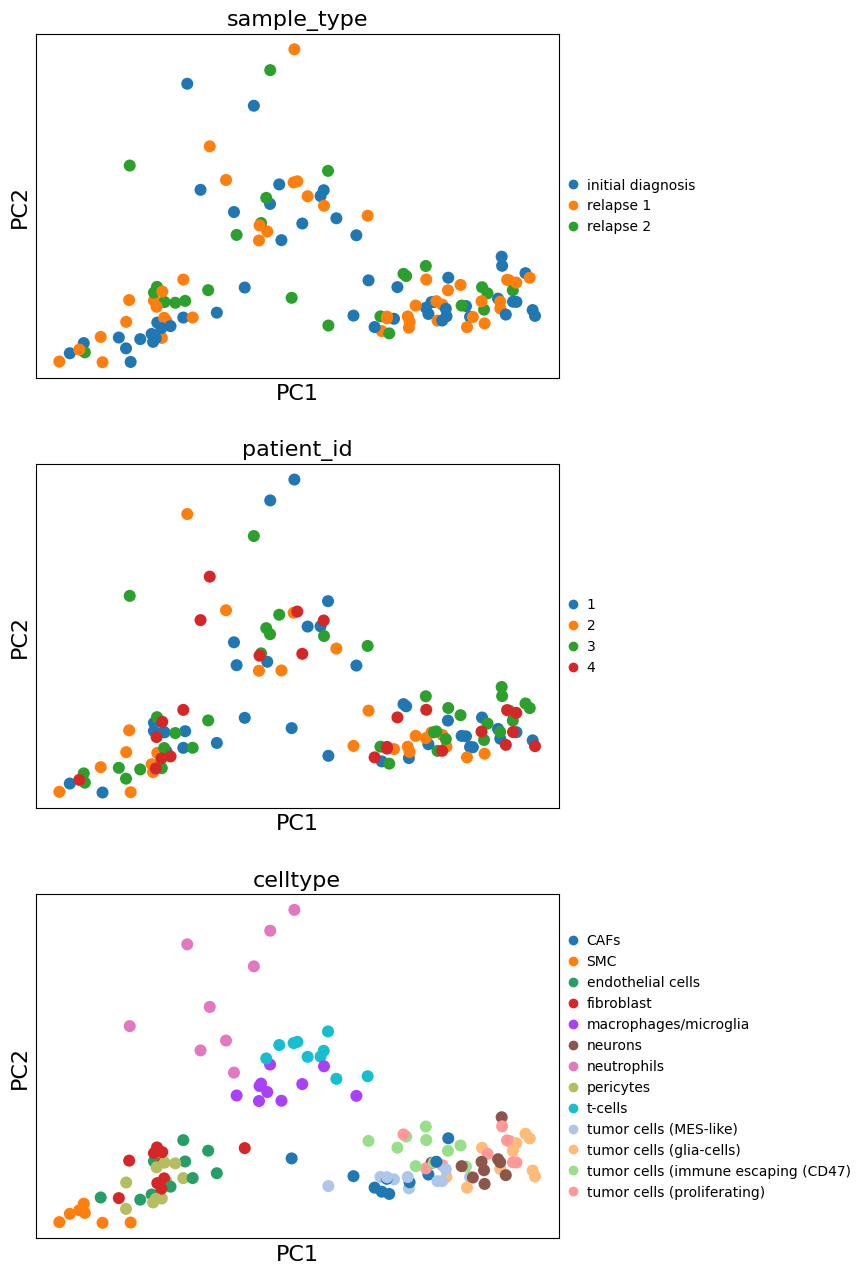

In [23]:
sc.pl.pca(
    pdata_without_neighborhood,
    color=["sample_type", "patient_id", "celltype"],
    ncols=1,
    size=300,
    frameon=True,
)

### Differential expressed genes between two conditions

In [24]:
endothelial_cells = pdata_without_neighborhood[pdata_without_neighborhood.obs["celltype"] == "endothelial cells"].copy()
endothelial_cells

AnnData object with n_obs × n_vars = 10 × 314
    obs: 'batch', 'celltype', 'patient_id', 'sample_type', 'psbulk_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'rank_obsm', 'sample_type_colors', 'patient_id_colors', 'celltype_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts', 'X'

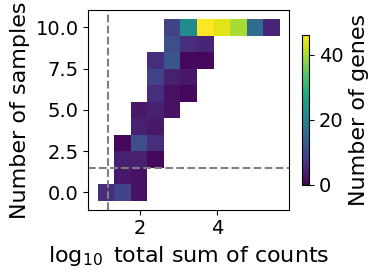

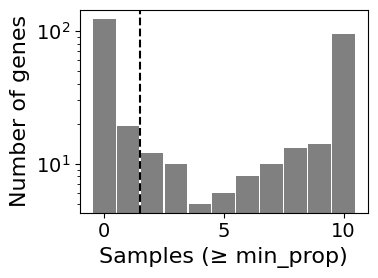

In [25]:
dc.pl.filter_by_expr(
    adata=endothelial_cells,
    group="sample_type",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pl.filter_by_prop(
    adata=endothelial_cells,
    min_prop=0.1,
    min_smpls=2,
)

In [26]:
dc.pp.filter_by_expr(
    adata=endothelial_cells,
    group="sample_type",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=endothelial_cells,
    min_prop=0.1,
    min_smpls=2,
)
endothelial_cells

AnnData object with n_obs × n_vars = 10 × 173
    obs: 'batch', 'celltype', 'patient_id', 'sample_type', 'psbulk_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'rank_obsm', 'sample_type_colors', 'patient_id_colors', 'celltype_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts', 'X'

In [27]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=endothelial_cells,
    design_factors=["sample_type"],
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res = DeseqStats(dds, contrast=["sample_type", "initial diagnosis", "relapse 1"], inference=inference)

# Compute Wald test
stat_res.summary()

Using None as control genes, passed at DeseqDataSet initialization


/var/folders/jr/048kfmrx5ddghsh_1l82f7280000gp/T/ipykernel_55975/3969521514.py:7: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.09 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.08 seconds.

Fitting LFCs...


Log2 fold change & Wald test p-value: sample_type initial diagnosis vs relapse 1
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
LYVE1     225.457951       -1.076654  0.614046 -1.753377  0.079537  0.324473
RERGL     266.165815       -0.550115  0.882804 -0.623145  0.533189  0.814066
THSD4     741.117906       -0.913300  0.634530 -1.439333  0.150056  0.442389
CDH11    2431.597716        0.479757  0.451145  1.063421  0.287591  0.592507
SLC12A4   270.803346       -0.392052  0.393939 -0.995208  0.319635  0.621109
...              ...             ...       ...       ...       ...       ...
CCL2      537.535842       -1.474902  0.529244 -2.786809  0.005323  0.086898
TIMP1    2184.135067       -0.050231  0.725870 -0.069201  0.944829  0.973387
NCAM1     304.987536       -0.382963  1.042050 -0.367509  0.713239  0.911373
QRICH1    586.251423        0.130914  0.201740  0.648927  0.516386  0.802745
PKM      2903.854698        0.049905  0.261024  0.191188  0.848378  0.97

... done in 0.08 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.08 seconds.



In [28]:
# Extract results
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
LYVE1,225.457951,-1.076654,0.614046,-1.753377,0.079537,0.324473
RERGL,266.165815,-0.550115,0.882804,-0.623145,0.533189,0.814066
THSD4,741.117906,-0.913300,0.634530,-1.439333,0.150056,0.442389
CDH11,2431.597716,0.479757,0.451145,1.063421,0.287591,0.592507
SLC12A4,270.803346,-0.392052,0.393939,-0.995208,0.319635,0.621109
...,...,...,...,...,...,...
CCL2,537.535842,-1.474902,0.529244,-2.786809,0.005323,0.086898
TIMP1,2184.135067,-0.050231,0.725870,-0.069201,0.944829,0.973387
NCAM1,304.987536,-0.382963,1.042050,-0.367509,0.713239,0.911373
QRICH1,586.251423,0.130914,0.201740,0.648927,0.516386,0.802745


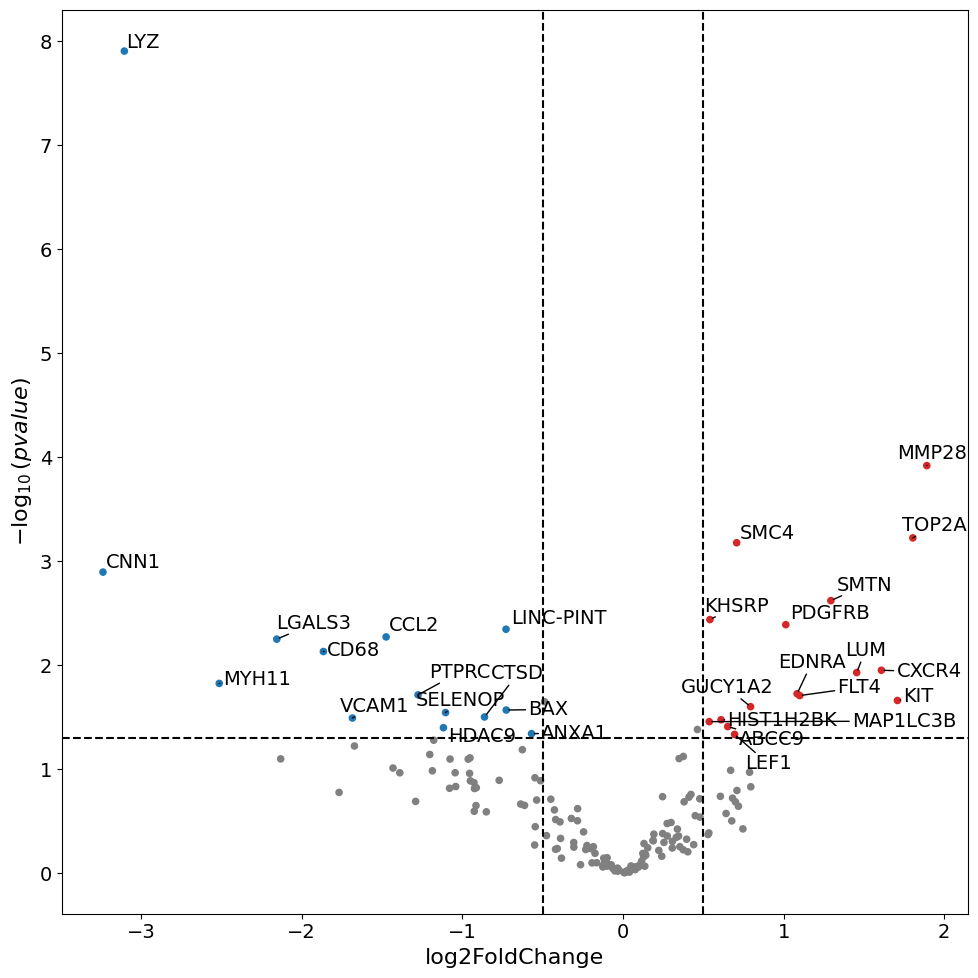

In [29]:
dc.pl.volcano(results_df, x="log2FoldChange", y="pvalue",figsize=(10,10),top=40)

In [30]:
data = results_df[["stat"]].T.rename(index={"stat": "initial diagnosis vs. relapse 1"})
data

,LYVE1,RERGL,THSD4,CDH11,SLC12A4,TEK,CDH6,ABCC9,DCN,SEMA3C,...,LYZ,GASK1B,RAMP2,KIT,VIM,CCL2,TIMP1,NCAM1,QRICH1,PKM
initial diagnosis vs. relapse 1,-1.753377,-0.623145,-1.439333,1.063421,-0.995208,-1.028959,0.687353,2.066873,0.301648,-0.1674,...,-5.694358,0.887789,-0.13899,2.294836,-0.171189,-2.786809,-0.069201,-0.367509,0.648927,0.191188


### Pathway analysis

In [31]:
progeny = dc.op.progeny(organism="human")
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
62416,p53,ENPP2,2.771405,4.993215e-02
62417,p53,ARRDC4,3.494328,4.996747e-02
62418,p53,MYO1B,-1.148057,4.997905e-02
62419,p53,CTSC,-1.784693,4.998864e-02


In [32]:
# Run
pw_acts, pw_padj = dc.mt.ulm(data=data, net=progeny)

# Filter by sign padj
msk = (pw_padj.T < 0.05).iloc[:, 0]
pw_acts = pw_acts.loc[:, msk]

pw_acts

,MAPK,p53
initial diagnosis vs. relapse 1,3.039614,-2.763113


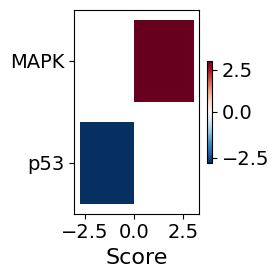

In [33]:
dc.pl.barplot(data=pw_acts, name="initial diagnosis vs. relapse 1", figsize=(3, 3))

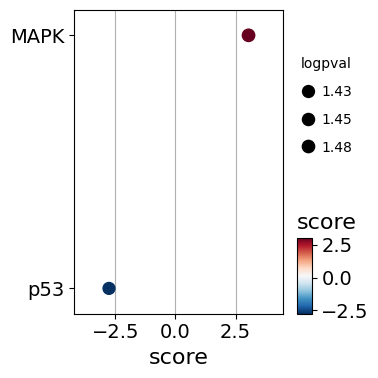

In [34]:
# Transform to df
import numpy as np

df = pw_acts.melt(value_name="score").merge(
    pw_padj.melt(value_name="pvalue")
    .assign(logpval=lambda x: x["pvalue"].clip(2.22e-4, 1))
    .assign(logpval=lambda x: -np.log10(x["logpval"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="logpval", c="score", scale=1, figsize=(4, 4))

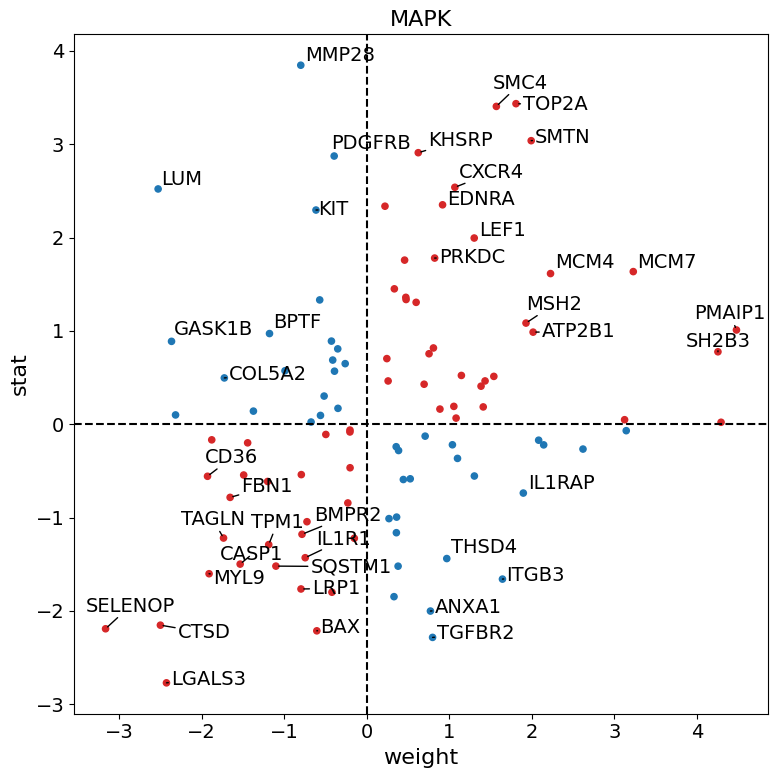

In [35]:
dc.pl.source_targets(data=results_df, x="weight", y="stat", net=progeny, name="MAPK", top=40, figsize=(8, 8))

(+) leading edge: ['TOP2A' 'SMC4' 'SMTN' 'KHSRP' 'CXCR4']
(-) leading edge: ['LGALS3' 'BAX' 'SELENOP' 'CTSD' 'ALOX5']


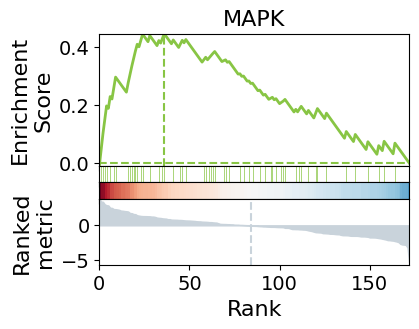

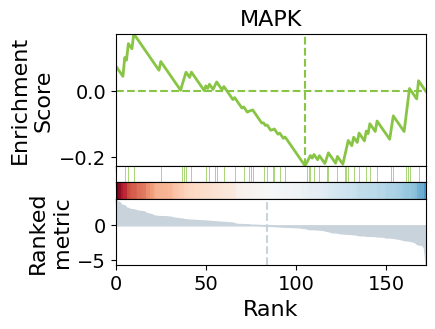

In [36]:
_, pos_le = dc.pl.leading_edge(
    results_df,
    stat="stat",
    net=progeny[progeny["weight"] > 0],
    name="MAPK",
)
print("(+) leading edge:", pos_le[:5])
_, neg_le = dc.pl.leading_edge(
    results_df,
    stat="stat",
    net=progeny[progeny["weight"] < 0],
    name="MAPK",
)
print("(-) leading edge:", neg_le[:5])

In [37]:
hallmark = dc.op.hallmark(organism="human")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF
...,...,...
7313,PANCREAS_BETA_CELLS,STXBP1
7314,PANCREAS_BETA_CELLS,ELP4
7315,PANCREAS_BETA_CELLS,GCG
7316,PANCREAS_BETA_CELLS,PCSK2


### Hallmark gene sets

In [38]:
# Run
hm_acts, hm_padj = dc.mt.ulm(data=data, net=hallmark)

# Filter by sign padj
msk = (hm_padj.T < 0.05).iloc[:, 0]
hm_acts = hm_acts.loc[:, msk]

hm_acts

,G2M_CHECKPOINT
initial diagnosis vs. relapse 1,3.198237


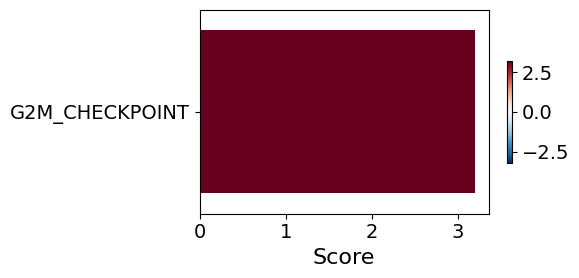

In [39]:
dc.pl.barplot(data=hm_acts, name="initial diagnosis vs. relapse 1", figsize=(6, 3))

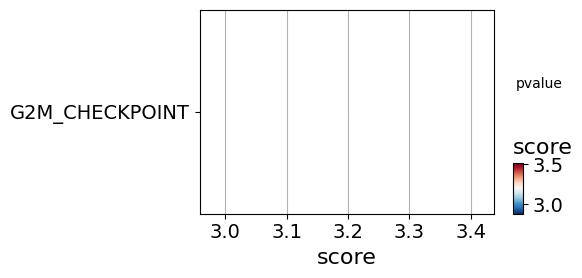

In [40]:
# Tranform to df
df = hm_acts.melt(value_name="score").merge(
    hm_padj.melt(value_name="pvalue")
    .assign(padj=lambda x: x["pvalue"].clip(2.22e-16, 1))
    .assign(padj=lambda x: np.log10(x["pvalue"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="pvalue", c="score", scale=0.25, figsize=(6, 3))

leading edge: ['TOP2A' 'SMC4' 'TGFB1' 'HMGN2']


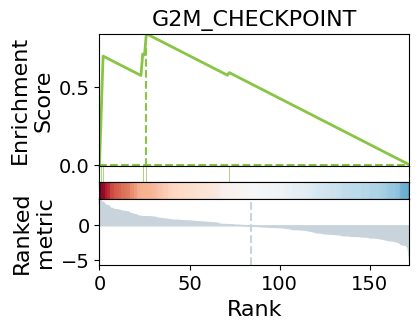

In [41]:
_, le = dc.pl.leading_edge(
    results_df,
    stat="stat",
    net=hallmark,
    name="G2M_CHECKPOINT",
)
print("leading edge:", le[:5])

### Generating pseudobulk with consideration of neighborhood

In [42]:
from insitupy.tools import generate_pseudobulk_neighbors

In [43]:
pdata=generate_pseudobulk_neighbors(exp=exp,cell_layer='proseg',raw_counts='round_raw_counts',sample_col='batch',groups_col='celltype',radius=20)

N-42-20-T


/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


N-1055-20-T


/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


N-480-21-T


...

/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


N-436-21-T


/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


N-851-22-T


/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [44]:
pdata

AnnData object with n_obs × n_vars = 258 × 314
    obs: 'batch', 'scale', 'patient_id', 'sample_type', 'tumor_area', '_scvi_batch', '_scvi_sample', 'psbulk_cells', 'psbulk_counts', 'celltype', 'neighbors'
    layers: 'psbulk_props'

In [45]:
pdata.obs

,batch,scale,patient_id,sample_type,tumor_area,_scvi_batch,_scvi_sample,psbulk_cells,psbulk_counts,celltype,neighbors
N-42-20-T_tumor cells (MES-like)_neighbors,N-42-20-T,1.0,1,initial diagnosis,tumor center,0,0,42849.0,7546458.0,tumor cells (MES-like),neighbors
N-42-20-T_tumor cells (glia-cells)_neighbors,N-42-20-T,1.0,1,initial diagnosis,tumor center,0,0,21360.0,3502892.0,tumor cells (glia-cells),neighbors
N-42-20-T_endothelial cells_neighbors,N-42-20-T,1.0,1,initial diagnosis,tumor center,0,0,12039.0,2026940.0,endothelial cells,neighbors
N-42-20-T_neurons_neighbors,N-42-20-T,1.0,1,initial diagnosis,tumor center,0,0,4999.0,836786.0,neurons,neighbors
N-42-20-T_macrophages/microglia_neighbors,N-42-20-T,1.0,1,initial diagnosis,tumor center,0,0,24945.0,4351931.0,macrophages/microglia,neighbors
...,...,...,...,...,...,...,...,...,...,...,...
N-851-22-T_t-cells,N-851-22-T,1.0,4,relapse 1,tumor center,5,5,1067.0,101432.0,t-cells,cell
N-851-22-T_tumor cells (MES-like),N-851-22-T,1.0,4,relapse 1,tumor center,5,5,8228.0,1890584.0,tumor cells (MES-like),cell
N-851-22-T_tumor cells (glia-cells),N-851-22-T,1.0,4,relapse 1,tumor center,5,5,270.0,35586.0,tumor cells (glia-cells),cell
N-851-22-T_tumor cells (immune escaping (CD47),N-851-22-T,1.0,4,relapse 1,tumor center,5,5,33411.0,3365696.0,tumor cells (immune escaping (CD47),cell


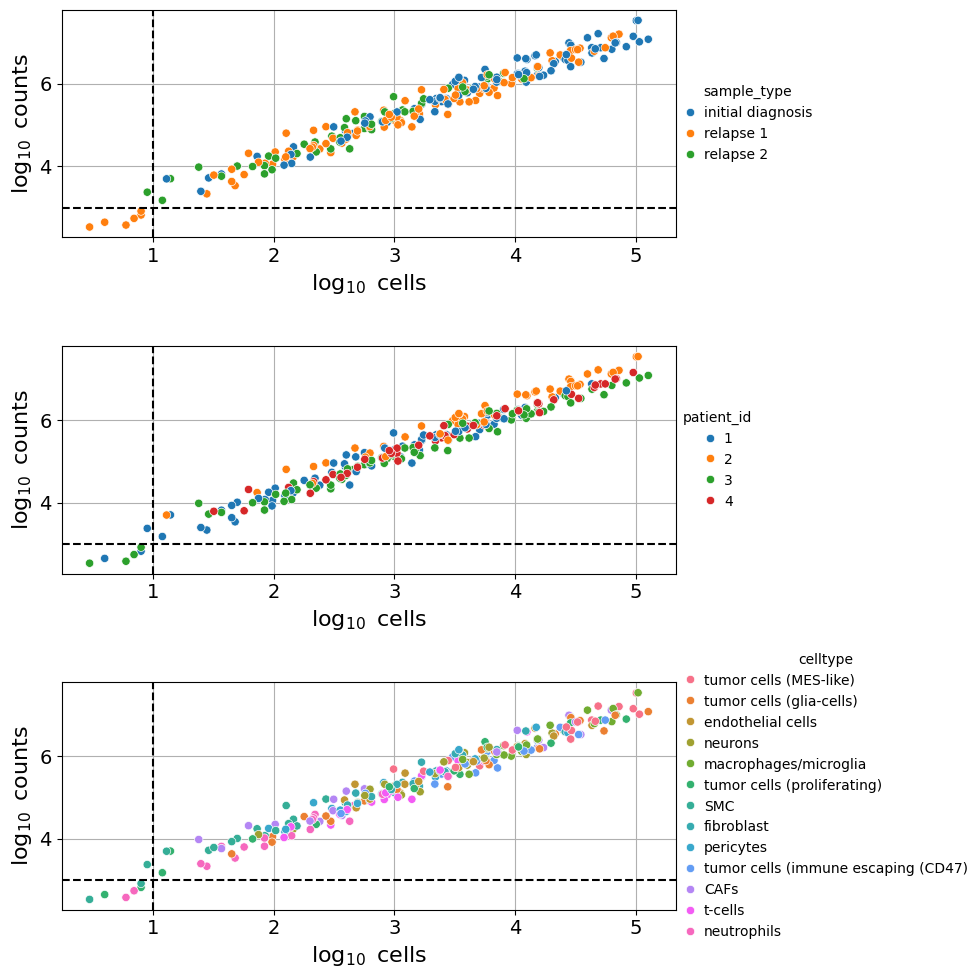

In [46]:
dc.pl.filter_samples(
    adata=pdata,
    groupby=["sample_type", "patient_id", "celltype"],
    min_cells=10,
    min_counts=1000,
    figsize=(10, 10),
)

In [47]:
dc.pp.filter_samples(pdata, min_cells=10, min_counts=1000)

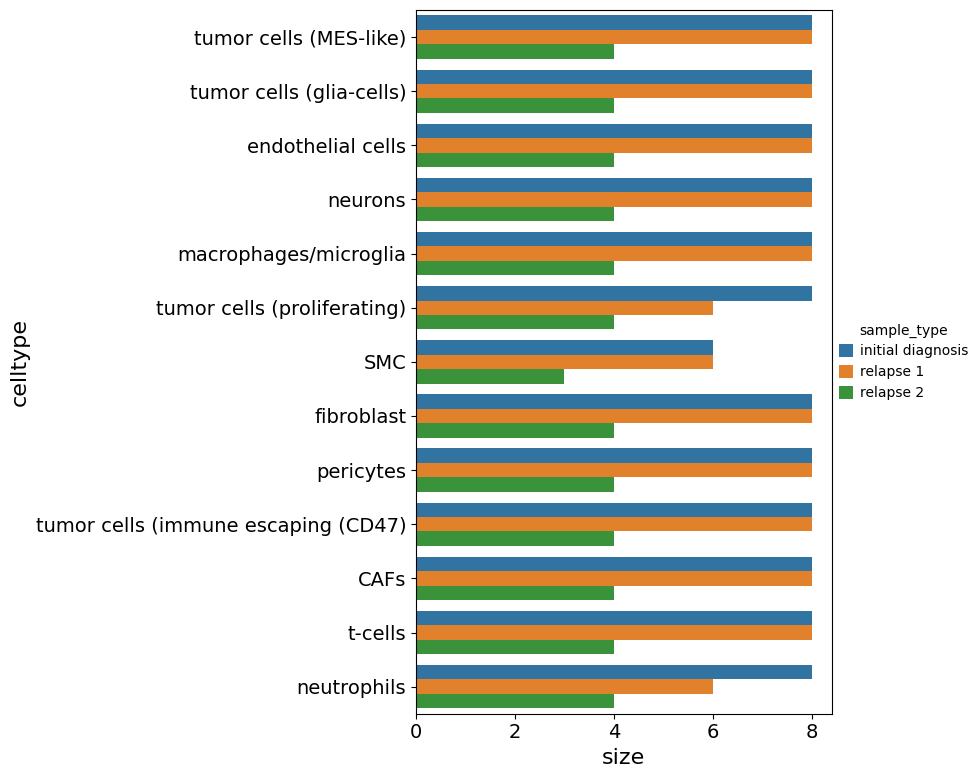

In [48]:
dc.pl.obsbar(adata=pdata, y="celltype", hue="sample_type", figsize=(10, 8))

In [49]:
# Store raw counts in layers
pdata.layers["counts"] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.pp.swap_layer(adata=pdata, key="counts", inplace=True)

In [50]:
pdata.obs.columns

Index(['batch', 'scale', 'patient_id', 'sample_type', 'tumor_area',
       '_scvi_batch', '_scvi_sample', 'psbulk_cells', 'psbulk_counts',
       'celltype', 'neighbors'],
      dtype='object')

#### all columns in obs must have at least 2 different features

In [51]:
del pdata.obs['tumor_area']
del pdata.obs['scale']
del pdata.obs['_scvi_batch']
del pdata.obs['_scvi_sample']

In [52]:
dc.tl.rankby_obsm(pdata, key="X_pca")

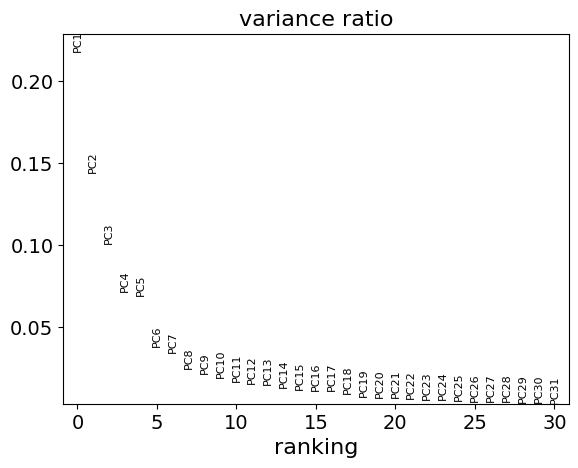

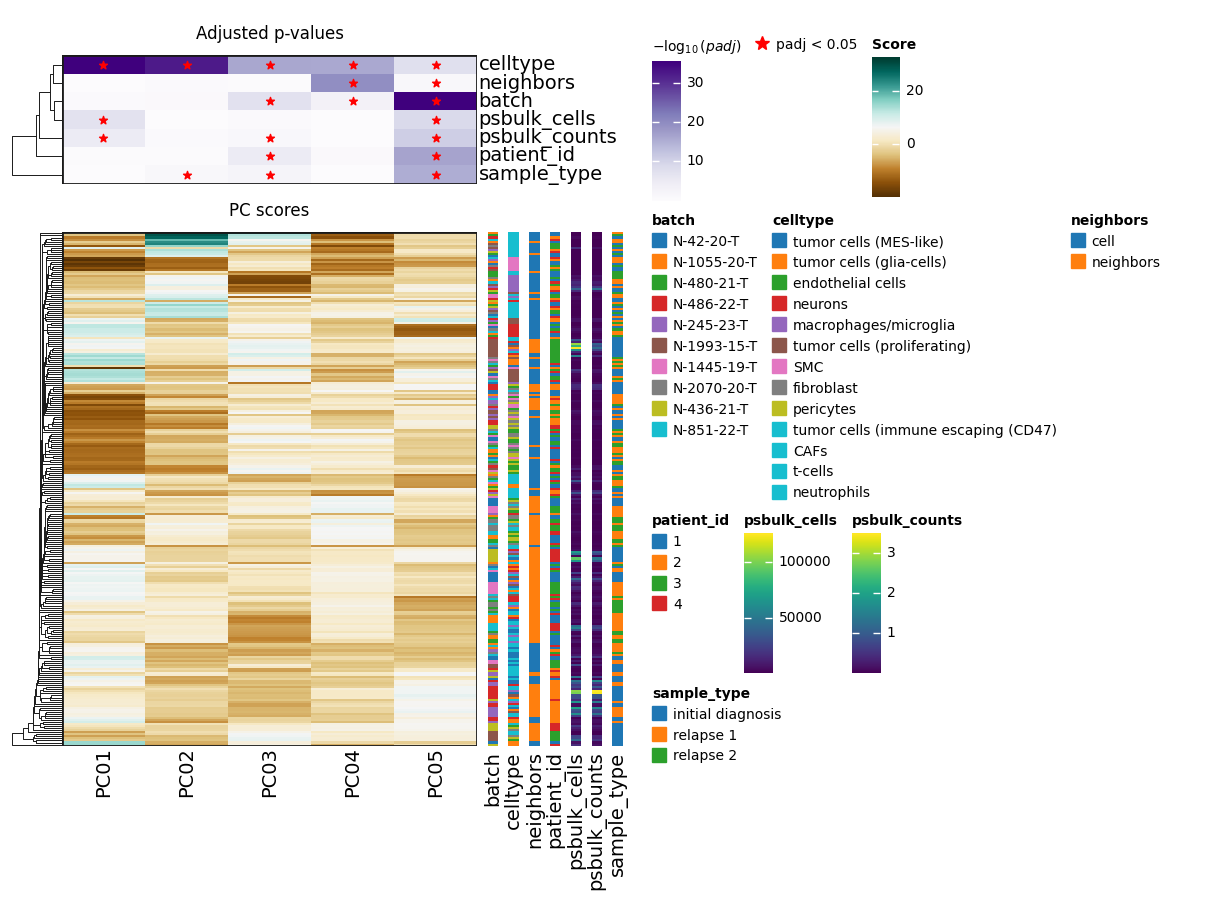

In [53]:
sc.pl.pca_variance_ratio(pdata)
dc.pl.obsm(adata=pdata, return_fig=True, nvar=5, titles=["PC scores", "Adjusted p-values"], figsize=(12, 8))

... storing 'neighbors' as categorical


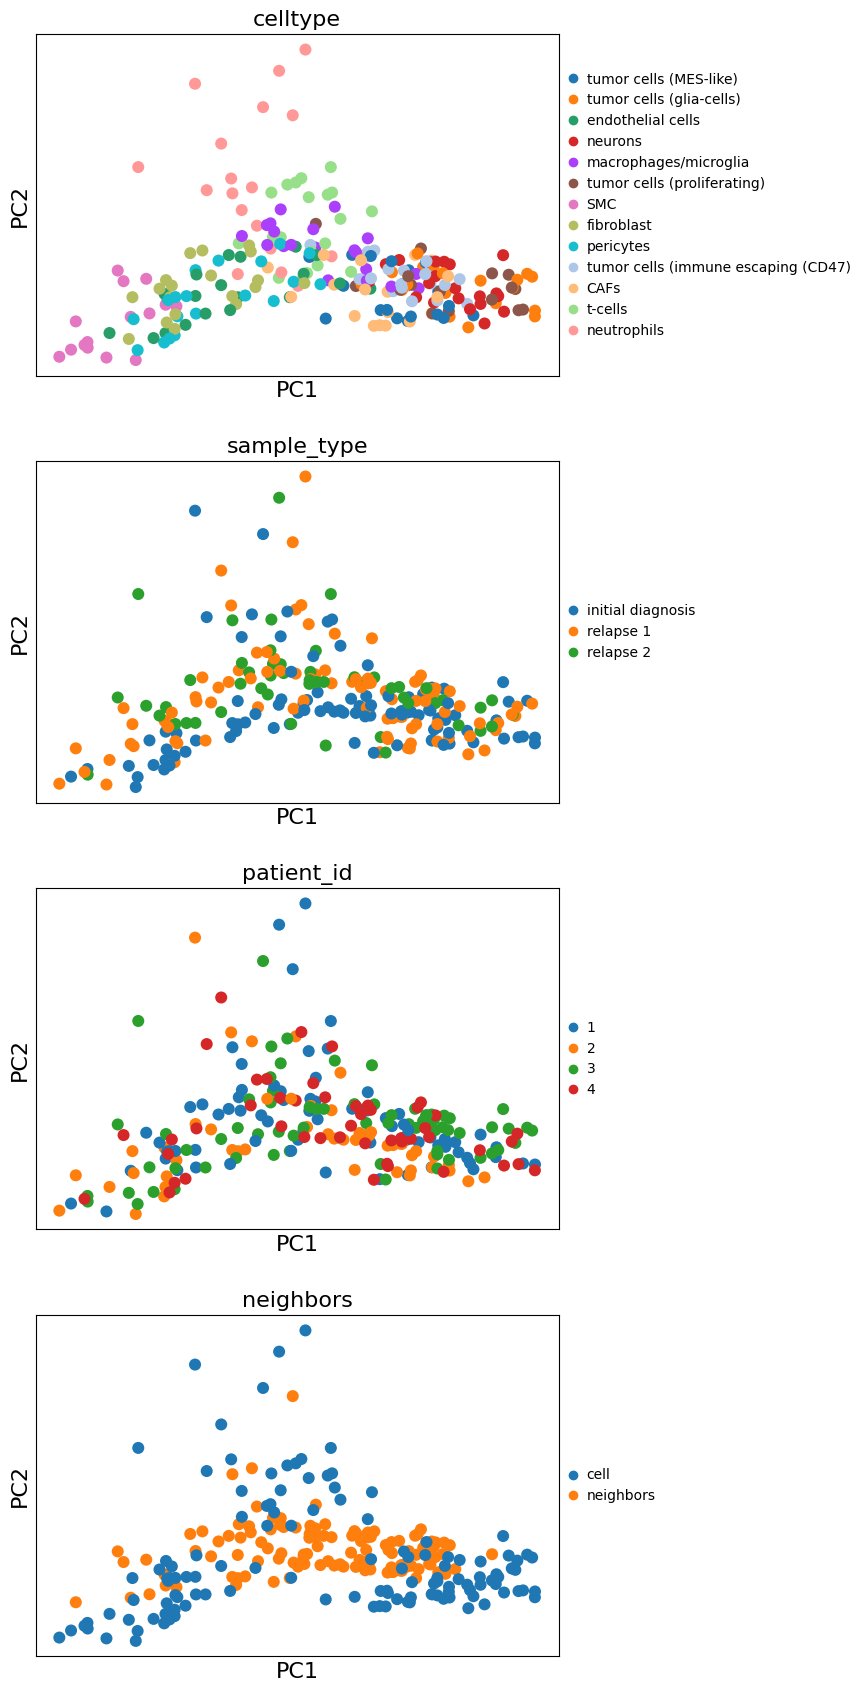

In [54]:
sc.pl.pca(
    pdata,
    color=["celltype", "sample_type", "patient_id","neighbors"],
    ncols=1,
    size=300,
    frameon=True,
)

### Differential expressed genes

In [55]:
endothelial_cells = pdata[pdata.obs["celltype"] == "endothelial cells"].copy()
endothelial_cells.obs

,batch,patient_id,sample_type,psbulk_cells,psbulk_counts,celltype,neighbors
N-42-20-T_endothelial cells_neighbors,N-42-20-T,1,initial diagnosis,12039.0,2026940.0,endothelial cells,neighbors
N-1055-20-T_endothelial cells_neighbors,N-1055-20-T,1,relapse 1,1119.0,128764.0,endothelial cells,neighbors
N-480-21-T_endothelial cells_neighbors,N-480-21-T,1,relapse 2,995.0,189984.0,endothelial cells,neighbors
N-486-22-T_endothelial cells_neighbors,N-486-22-T,2,initial diagnosis,14544.0,4825481.0,endothelial cells,neighbors
N-245-23-T_endothelial cells_neighbors,N-245-23-T,2,relapse 1,1223.0,390529.0,endothelial cells,neighbors
N-1993-15-T_endothelial cells_neighbors,N-1993-15-T,3,initial diagnosis,43088.0,5627598.0,endothelial cells,neighbors
N-1445-19-T_endothelial cells_neighbors,N-1445-19-T,3,relapse 1,1488.0,174825.0,endothelial cells,neighbors
N-2070-20-T_endothelial cells_neighbors,N-2070-20-T,3,relapse 2,2334.0,378043.0,endothelial cells,neighbors
N-436-21-T_endothelial cells_neighbors,N-436-21-T,4,initial diagnosis,20796.0,3096079.0,endothelial cells,neighbors
N-851-22-T_endothelial cells_neighbors,N-851-22-T,4,relapse 1,5624.0,799805.0,endothelial cells,neighbors


In [56]:
endo_cells=endothelial_cells[endothelial_cells.obs['neighbors']=='cell']

In [57]:
endo_neighbors=endothelial_cells[endothelial_cells.obs['sample_type']=='initial diagnosis']

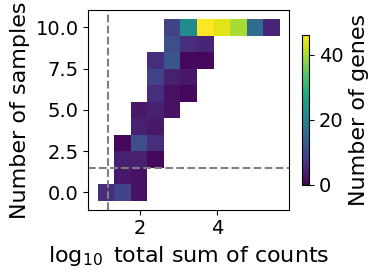

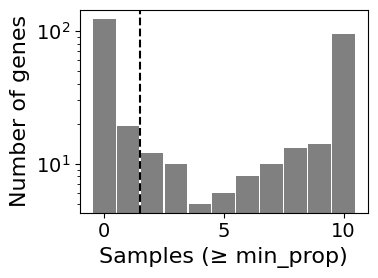

In [58]:
dc.pl.filter_by_expr(
    adata=endo_cells,
    group="sample_type",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pl.filter_by_prop(
    adata=endo_cells,
    min_prop=0.1,
    min_smpls=2,
)

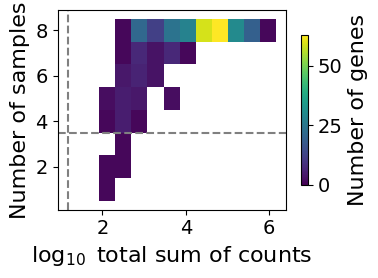

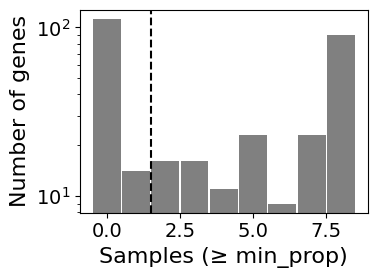

In [59]:
dc.pl.filter_by_expr(
    adata=endo_neighbors,
    group="neighbors",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pl.filter_by_prop(
    adata=endo_neighbors,
    min_prop=0.1,
    min_smpls=2,
)

In [60]:
dc.pp.filter_by_expr(
    adata=endo_cells,
    group="sample_type",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=endo_cells,
    min_prop=0.1,
    min_smpls=2,
)
endo_cells.obs

,batch,patient_id,sample_type,psbulk_cells,psbulk_counts,celltype,neighbors
N-42-20-T_endothelial cells,N-42-20-T,1,initial diagnosis,3400.0,527758.0,endothelial cells,cell
N-1055-20-T_endothelial cells,N-1055-20-T,1,relapse 1,481.0,56297.0,endothelial cells,cell
N-480-21-T_endothelial cells,N-480-21-T,1,relapse 2,385.0,86849.0,endothelial cells,cell
N-486-22-T_endothelial cells,N-486-22-T,2,initial diagnosis,3423.0,1404946.0,endothelial cells,cell
N-245-23-T_endothelial cells,N-245-23-T,2,relapse 1,470.0,209756.0,endothelial cells,cell
N-1993-15-T_endothelial cells,N-1993-15-T,3,initial diagnosis,10353.0,1729130.0,endothelial cells,cell
N-1445-19-T_endothelial cells,N-1445-19-T,3,relapse 1,625.0,91641.0,endothelial cells,cell
N-2070-20-T_endothelial cells,N-2070-20-T,3,relapse 2,1216.0,210141.0,endothelial cells,cell
N-436-21-T_endothelial cells,N-436-21-T,4,initial diagnosis,4497.0,740421.0,endothelial cells,cell
N-851-22-T_endothelial cells,N-851-22-T,4,relapse 1,1586.0,245800.0,endothelial cells,cell


In [61]:
dc.pp.filter_by_expr(
    adata=endo_neighbors,
    group="neighbors",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=endo_neighbors,
    min_prop=0.1,
    min_smpls=2,
)
endo_neighbors.obs

,batch,patient_id,sample_type,psbulk_cells,psbulk_counts,celltype,neighbors
N-42-20-T_endothelial cells_neighbors,N-42-20-T,1,initial diagnosis,12039.0,2026940.0,endothelial cells,neighbors
N-486-22-T_endothelial cells_neighbors,N-486-22-T,2,initial diagnosis,14544.0,4825481.0,endothelial cells,neighbors
N-1993-15-T_endothelial cells_neighbors,N-1993-15-T,3,initial diagnosis,43088.0,5627598.0,endothelial cells,neighbors
N-436-21-T_endothelial cells_neighbors,N-436-21-T,4,initial diagnosis,20796.0,3096079.0,endothelial cells,neighbors
N-42-20-T_endothelial cells,N-42-20-T,1,initial diagnosis,3400.0,527758.0,endothelial cells,cell
N-486-22-T_endothelial cells,N-486-22-T,2,initial diagnosis,3423.0,1404946.0,endothelial cells,cell
N-1993-15-T_endothelial cells,N-1993-15-T,3,initial diagnosis,10353.0,1729130.0,endothelial cells,cell
N-436-21-T_endothelial cells,N-436-21-T,4,initial diagnosis,4497.0,740421.0,endothelial cells,cell


In [62]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=endo_cells,
    design_factors=["sample_type"],
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res = DeseqStats(dds, contrast=["sample_type", "initial diagnosis", "relapse 1"], inference=inference)

# Compute Wald test
stat_res.summary()

/var/folders/jr/048kfmrx5ddghsh_1l82f7280000gp/T/ipykernel_55975/545575874.py:7: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.09 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.07 seconds.

Fitting LFCs...


Log2 fold change & Wald test p-value: sample_type initial diagnosis vs relapse 1
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
LYVE1     225.457951       -1.076654  0.614046 -1.753377  0.079537  0.324473
RERGL     266.165815       -0.550115  0.882804 -0.623145  0.533189  0.814066
THSD4     741.117906       -0.913300  0.634530 -1.439333  0.150056  0.442389
CDH11    2431.597716        0.479757  0.451145  1.063421  0.287591  0.592507
SLC12A4   270.803346       -0.392052  0.393939 -0.995208  0.319635  0.621109
...              ...             ...       ...       ...       ...       ...
CCL2      537.535842       -1.474902  0.529244 -2.786809  0.005323  0.086898
TIMP1    2184.135067       -0.050231  0.725870 -0.069201  0.944829  0.973387
NCAM1     304.987536       -0.382963  1.042050 -0.367509  0.713239  0.911373
QRICH1    586.251423        0.130914  0.201740  0.648927  0.516386  0.802745
PKM      2903.854698        0.049905  0.261024  0.191188  0.848378  0.97

... done in 0.06 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.10 seconds.



In [63]:
# Extract results
results_df_endo = stat_res.results_df
results_df_endo

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
LYVE1,225.457951,-1.076654,0.614046,-1.753377,0.079537,0.324473
RERGL,266.165815,-0.550115,0.882804,-0.623145,0.533189,0.814066
THSD4,741.117906,-0.913300,0.634530,-1.439333,0.150056,0.442389
CDH11,2431.597716,0.479757,0.451145,1.063421,0.287591,0.592507
SLC12A4,270.803346,-0.392052,0.393939,-0.995208,0.319635,0.621109
...,...,...,...,...,...,...
CCL2,537.535842,-1.474902,0.529244,-2.786809,0.005323,0.086898
TIMP1,2184.135067,-0.050231,0.725870,-0.069201,0.944829,0.973387
NCAM1,304.987536,-0.382963,1.042050,-0.367509,0.713239,0.911373
QRICH1,586.251423,0.130914,0.201740,0.648927,0.516386,0.802745


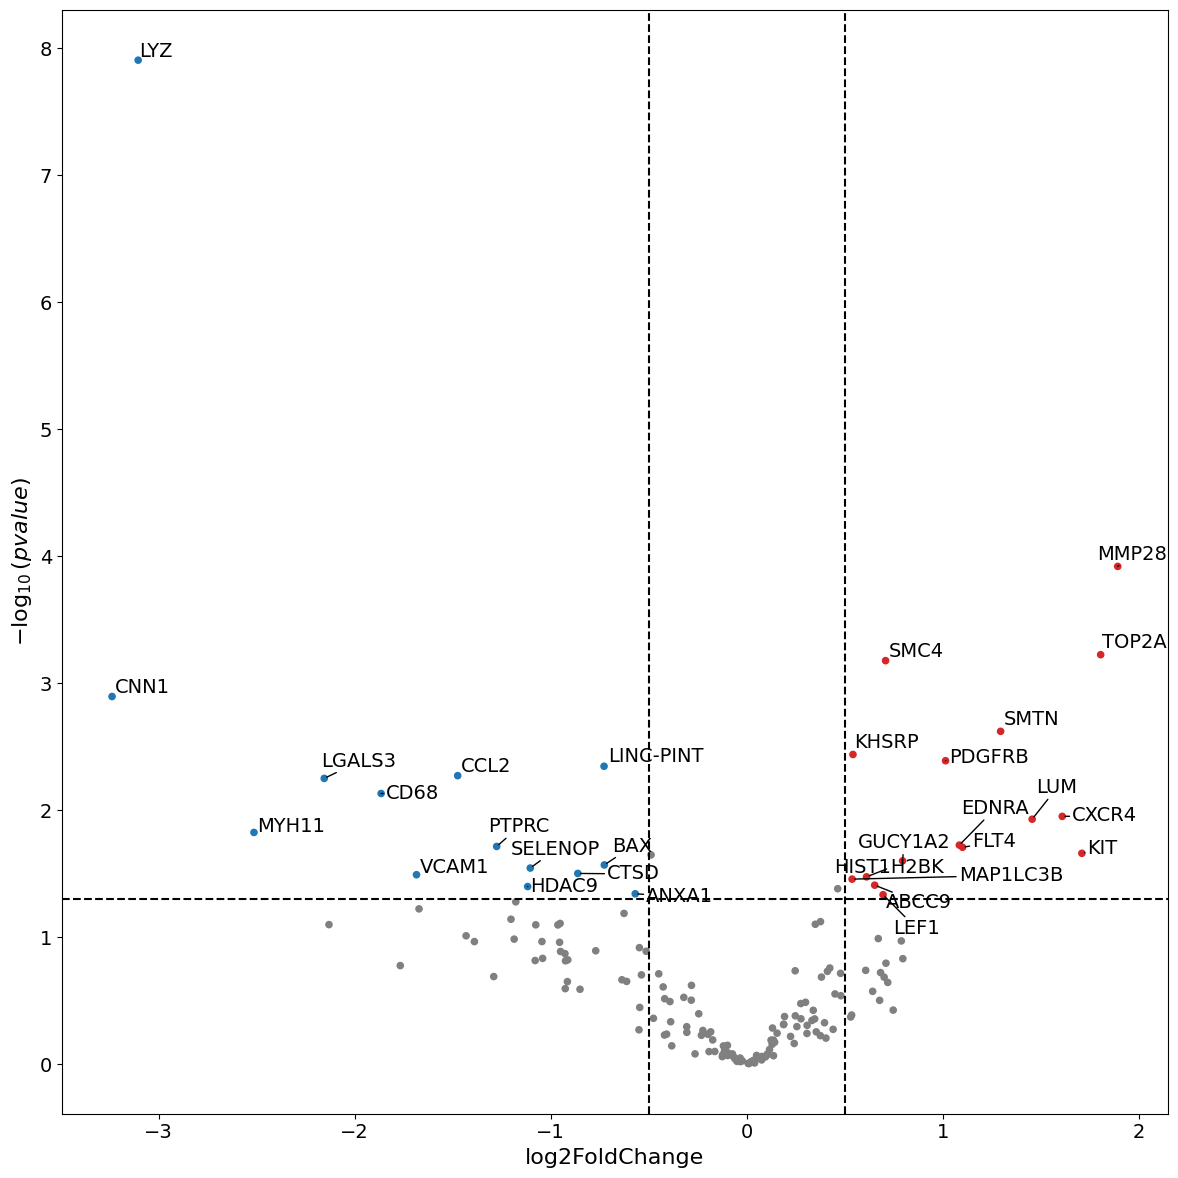

In [64]:
dc.pl.volcano(results_df_endo, x="log2FoldChange", y="pvalue",figsize=(12,12),top=40)

In [65]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=endo_neighbors,
    design_factors=["neighbors"],
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res = DeseqStats(dds, contrast=["neighbors", "cell", "neighbors"], inference=inference)

# Compute Wald test
stat_res.summary()

/var/folders/jr/048kfmrx5ddghsh_1l82f7280000gp/T/ipykernel_55975/2334804966.py:7: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.06 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.07 seconds.

Fitting LFCs...


Using None as control genes, passed at DeseqDataSet initialization
Log2 fold change & Wald test p-value: neighbors cell vs neighbors
             baseMean  log2FoldChange     lfcSE      stat        pvalue  \
LYVE1     1095.146754       -0.347860  0.861936 -0.403580  6.865216e-01   
PDGFRA    2558.469753       -3.375796  0.651421 -5.182205  2.192781e-07   
THSD4     2094.898342        2.547542  0.729462  3.492359  4.787743e-04   
SLC36A1    783.424183       -2.258781  0.641334 -3.522003  4.282988e-04   
CDH11    17805.453515        0.750004  0.411218  1.823860  6.817319e-02   
...               ...             ...       ...       ...           ...   
CCL2      3823.741753       -1.874375  0.688626 -2.721907  6.490646e-03   
TIMP1    15948.886762        0.277348  0.554909  0.499808  6.172103e-01   
NCAM1     9347.244987       -3.754140  0.739584 -5.076013  3.854374e-07   
QRICH1    4479.073807        0.184723  0.331672  0.556946  5.775640e-01   
PKM      25104.941955       -0.520965  0.3

... done in 0.06 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.06 seconds.



In [66]:
# Extract results
results_df_neighbors = stat_res.results_df
results_df_neighbors

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
LYVE1,1095.146754,-0.347860,0.861936,-0.403580,6.865216e-01,0.788147
PDGFRA,2558.469753,-3.375796,0.651421,-5.182205,2.192781e-07,0.000002
THSD4,2094.898342,2.547542,0.729462,3.492359,4.787743e-04,0.001791
SLC36A1,783.424183,-2.258781,0.641334,-3.522003,4.282988e-04,0.001669
CDH11,17805.453515,0.750004,0.411218,1.823860,6.817319e-02,0.131427
...,...,...,...,...,...,...
CCL2,3823.741753,-1.874375,0.688626,-2.721907,6.490646e-03,0.018673
TIMP1,15948.886762,0.277348,0.554909,0.499808,6.172103e-01,0.730496
NCAM1,9347.244987,-3.754140,0.739584,-5.076013,3.854374e-07,0.000003
QRICH1,4479.073807,0.184723,0.331672,0.556946,5.775640e-01,0.710556


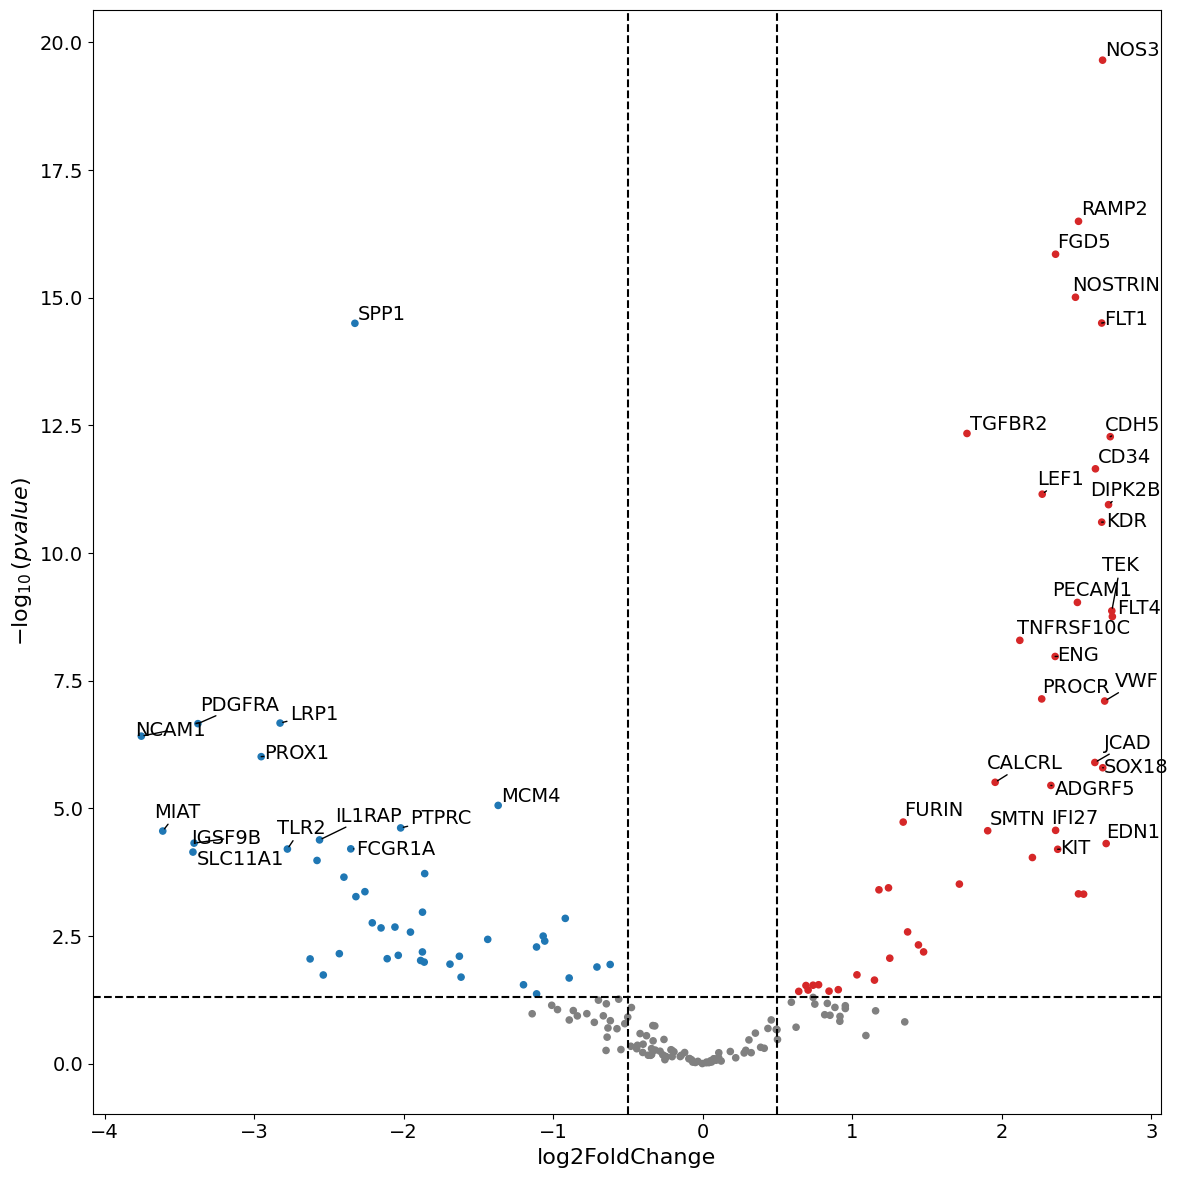

In [67]:
dc.pl.volcano(results_df_neighbors, x="log2FoldChange", y="pvalue",figsize=(12,12),top=40)

### Differential expressed genes with Consideration of gene expression in neighboring cells of target dataset

In [68]:
from insitupy.tools import two_sides_volcano

['FLT4', 'EDNRA', 'SMTN', 'LUM', 'TOP2A', 'PDGFRB', 'MMP28', 'CXCR4', 'KIT']


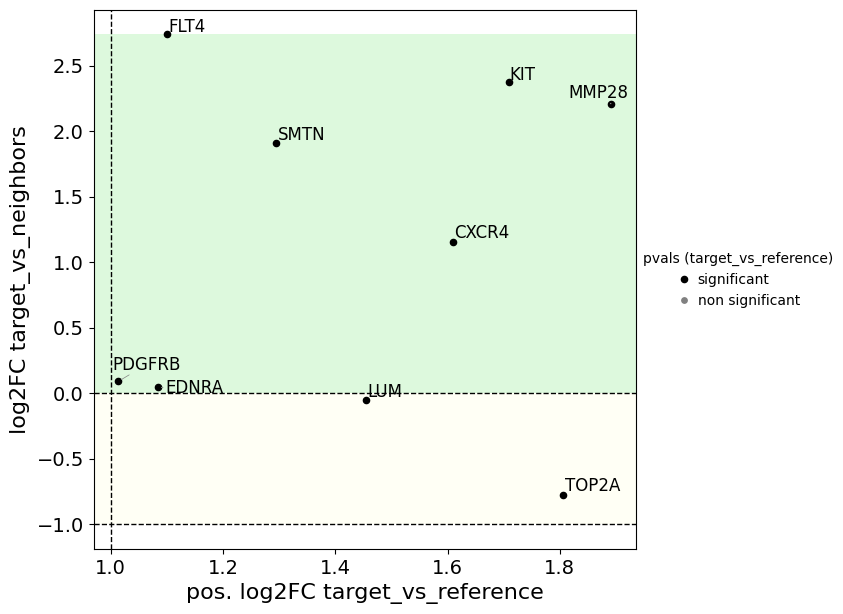

,gene,log2FoldChange_target_vs_reference,pvalue,log2FoldChange_target_vs_neighbors,neg_log10_pvals
0,FLT4,1.100439,0.019501,2.739784,1.709944
1,EDNRA,1.084146,0.018737,0.044220,1.727297
2,SMTN,1.294554,0.002383,1.906086,2.622944
3,LUM,1.455480,0.011714,-0.049129,1.931295
4,TOP2A,1.805004,0.000594,-0.774683,3.226281
5,PDGFRB,1.013768,0.004060,0.089894,2.391448
6,MMP28,1.891970,0.000120,2.205049,3.921329
7,CXCR4,1.609062,0.011133,1.156490,1.953398
8,KIT,1.709121,0.021743,2.374195,1.662690


In [69]:
two_sides_volcano(results_df_normal=results_df_endo,results_df_neighbors=results_df_neighbors,significance_threshold=0.05,fold_change_threshold=1.0)